# 1. From Correlation to Linear Regression - Fuel Consumption

Source: Dataset FuelConsumption.csv provided by the university

The exercise explores relationships between vehicles characteristsics and fuel consumption using correlation analysis before applying linear regression to model and predict CO2 ommission.

# 2. China GDP - Non Linear Regression example
Source: Dataset china_gdp.csv provided by the university


### Importing the required packages

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import seaborn as sns

### Load the data

In [3]:
# Reading the data
df=pd.read_csv("data/FuelConsumption.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [5]:
df.shape

(1067, 13)

In [6]:
# Take a look at the dataset
df.head(10)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,2014,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
6,2014,ACURA,TL,MID-SIZE,3.5,6,AS6,Z,11.8,8.1,10.1,28,232
7,2014,ACURA,TL AWD,MID-SIZE,3.7,6,AS6,Z,12.8,9.0,11.1,25,255
8,2014,ACURA,TL AWD,MID-SIZE,3.7,6,M6,Z,13.4,9.5,11.6,24,267
9,2014,ACURA,TSX,COMPACT,2.4,4,AS5,Z,10.6,7.5,9.2,31,212


In [7]:
df.isna().sum()

MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64

Data has 1067 observation, 13 variables with categorical and numerical values. 
Duplicated values are observed across many variables. No missing values detected.

In [8]:
# Checking correlation for numerical values.
df.corr(numeric_only=True)

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
MODELYEAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENGINESIZE,NaN,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,NaN,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,NaN,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,NaN,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,NaN,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,NaN,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,NaN,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


Correlation result shows that Modelyear has NaN value despite being numeric. Investigating the variable.

In [9]:
df['MODELYEAR'].nunique()

1

In [10]:
df['MODELYEAR'].std()

np.float64(0.0)

One unique value 2014 explain lack of correlation values. Given that modelyear has zero variance, the corrleation could not be calculated. The variable does not have predictive power.

### Relationshiop between each indidivual numerical variables. 

What to look at:
* Symmetry vs skewness
* Concentration of observations
* Long tails
* Unusual shapes

- Direction: positive or negative?
- Strength: tight or scattered?
- Form: linear or curved?
- Outliers: unusual observations?
- Spread: does variability change across the range?

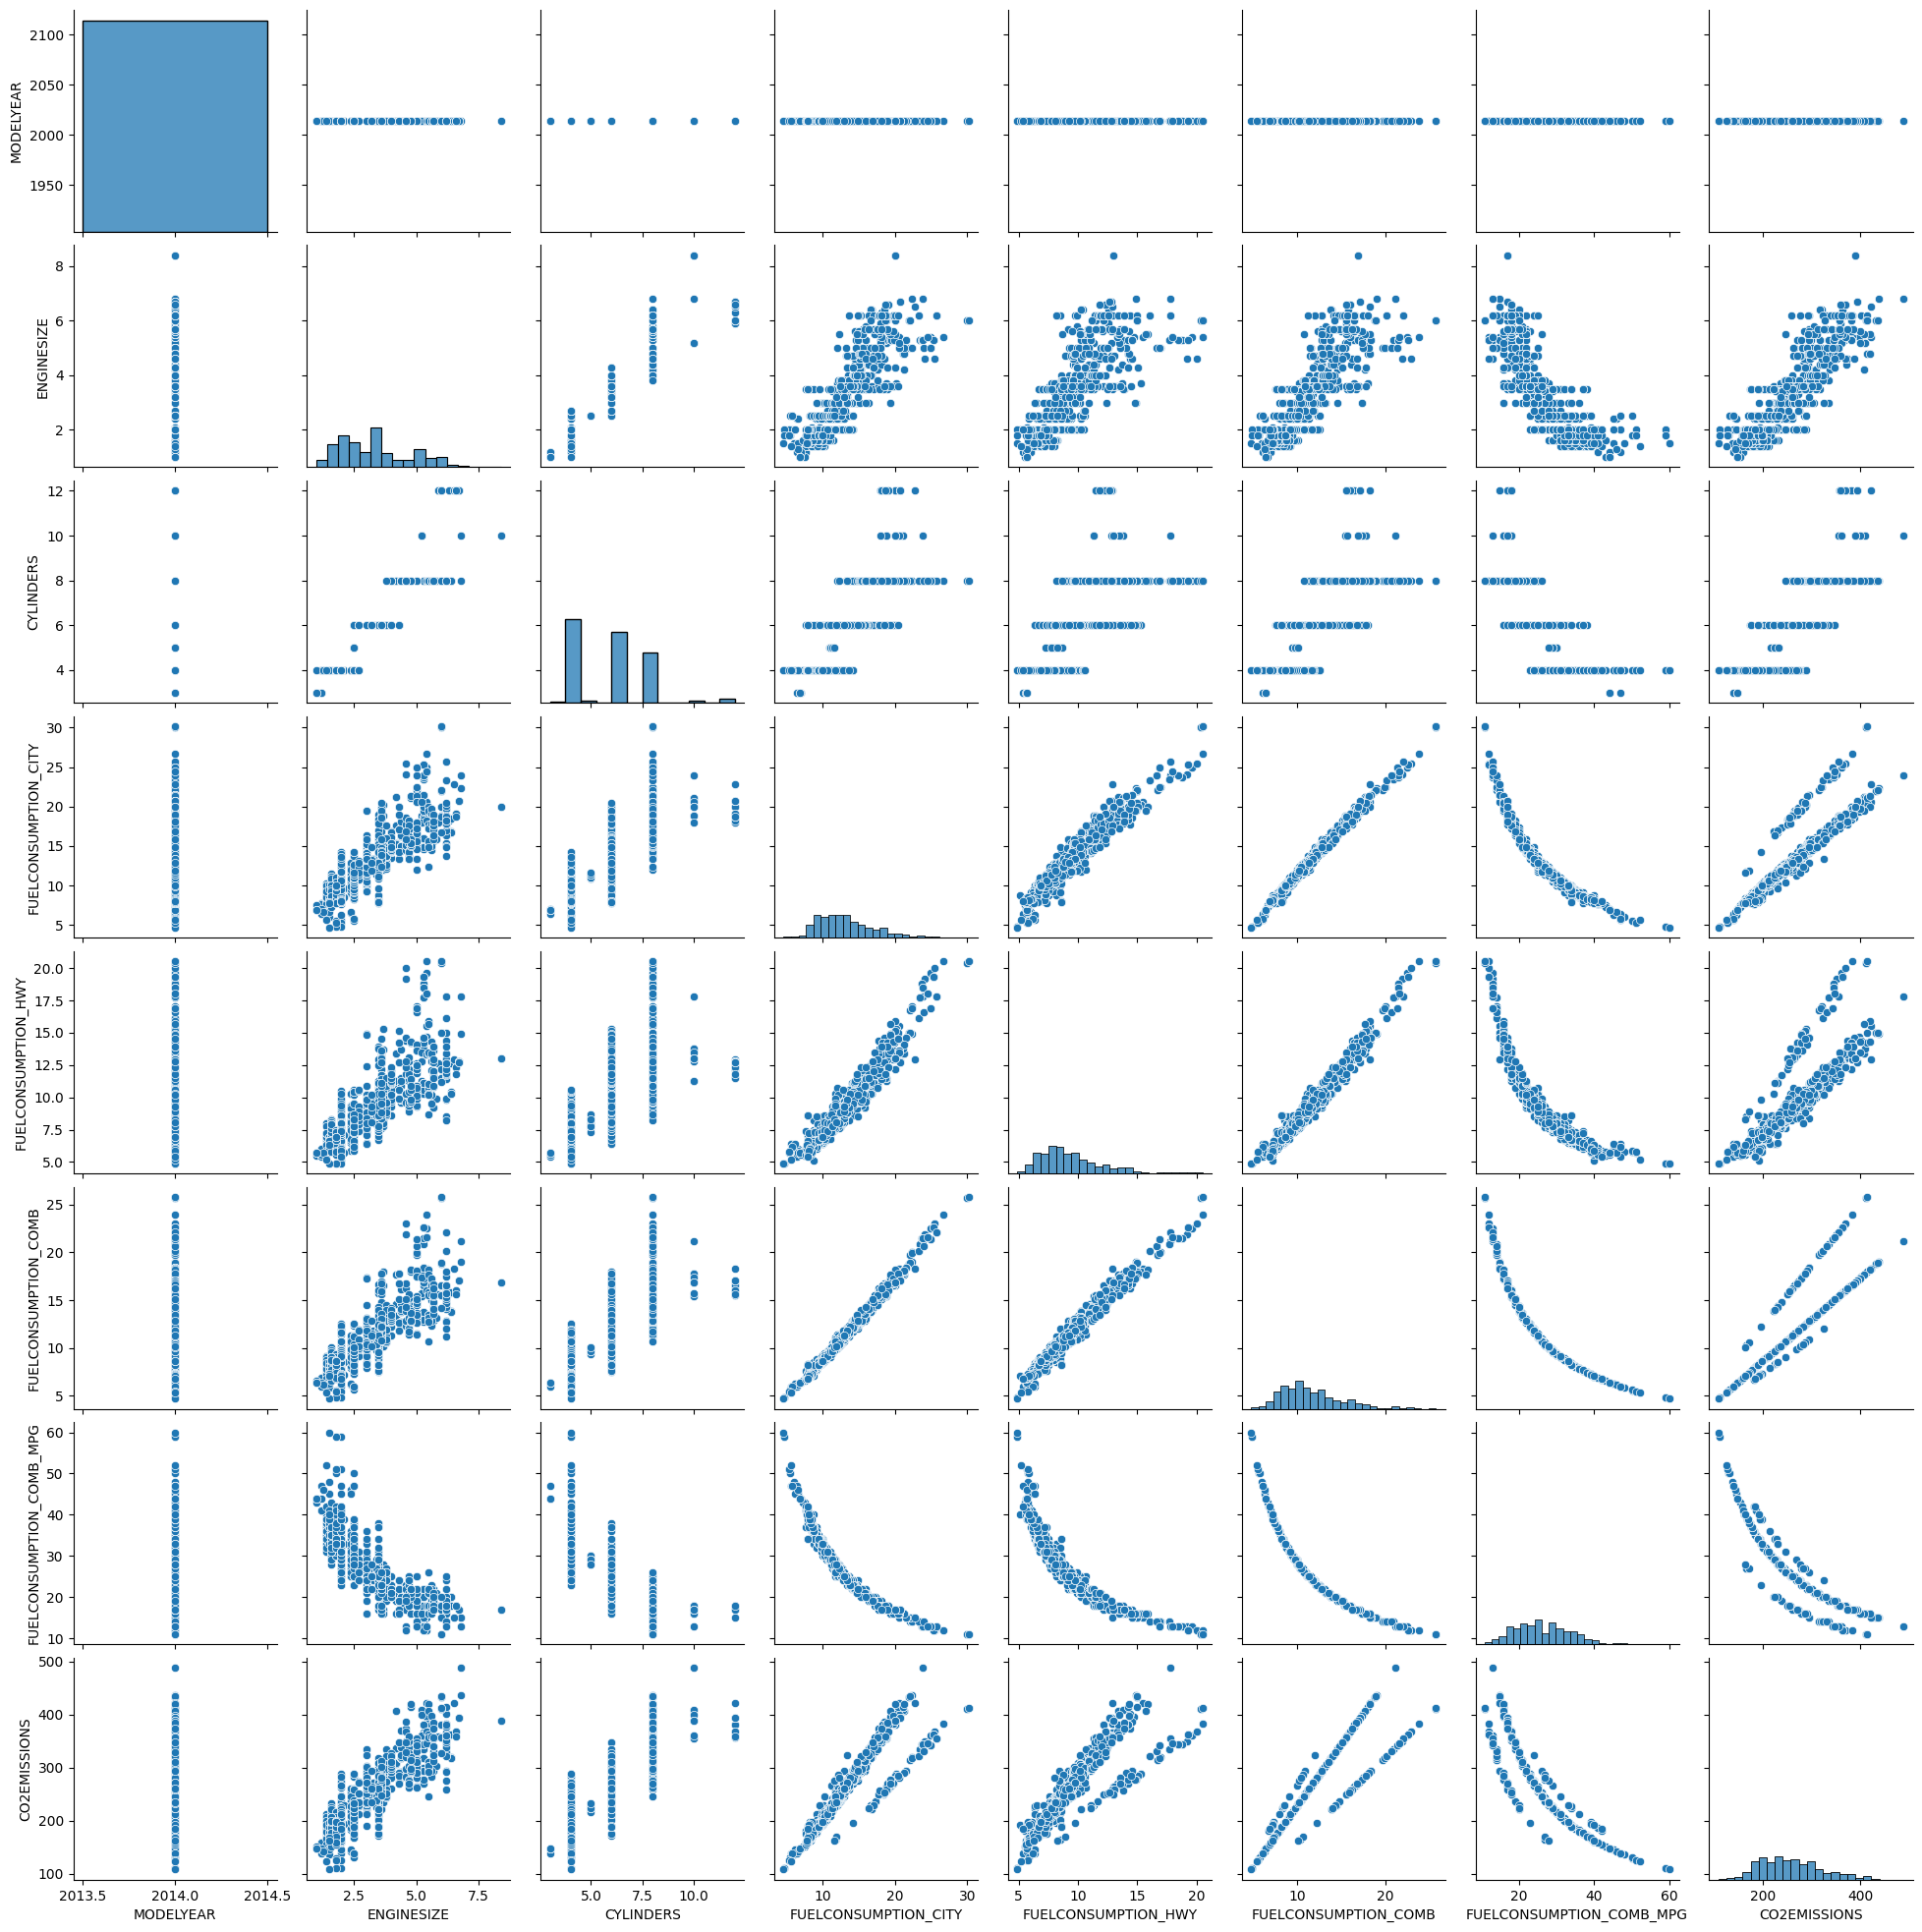

In [11]:
#Invstigating relationships between numeric variables
sns.pairplot(df)

* Model Year has only one value, so it has no variance, and connot show meanigful relationship with other variables (Vertical line)
* Cylinders although numeric but has a few discret values (bands lines of observations)
* Several variables have a mildly to moderately right-skewed distribution. The majority of observations are concentrated at lower/middle values, with longer tails (diagonal plots).
* Some variable pairs shows clea positive relationships (upward trend), while other negative (downward pattern)
* Some varable pairs show curved patterns, suggesting for non-linear relationships. Further investigation needed.
* Some variables show a few banded concentrations due to repeated/distrate values shared across vehicles.

Concluding: The pairplot suggest several positive, negative relationships between numerical variables, with some approximately linear and some non-linear. Discrete Variable such as Cylinder create bands, while Model Year has no useful variations.

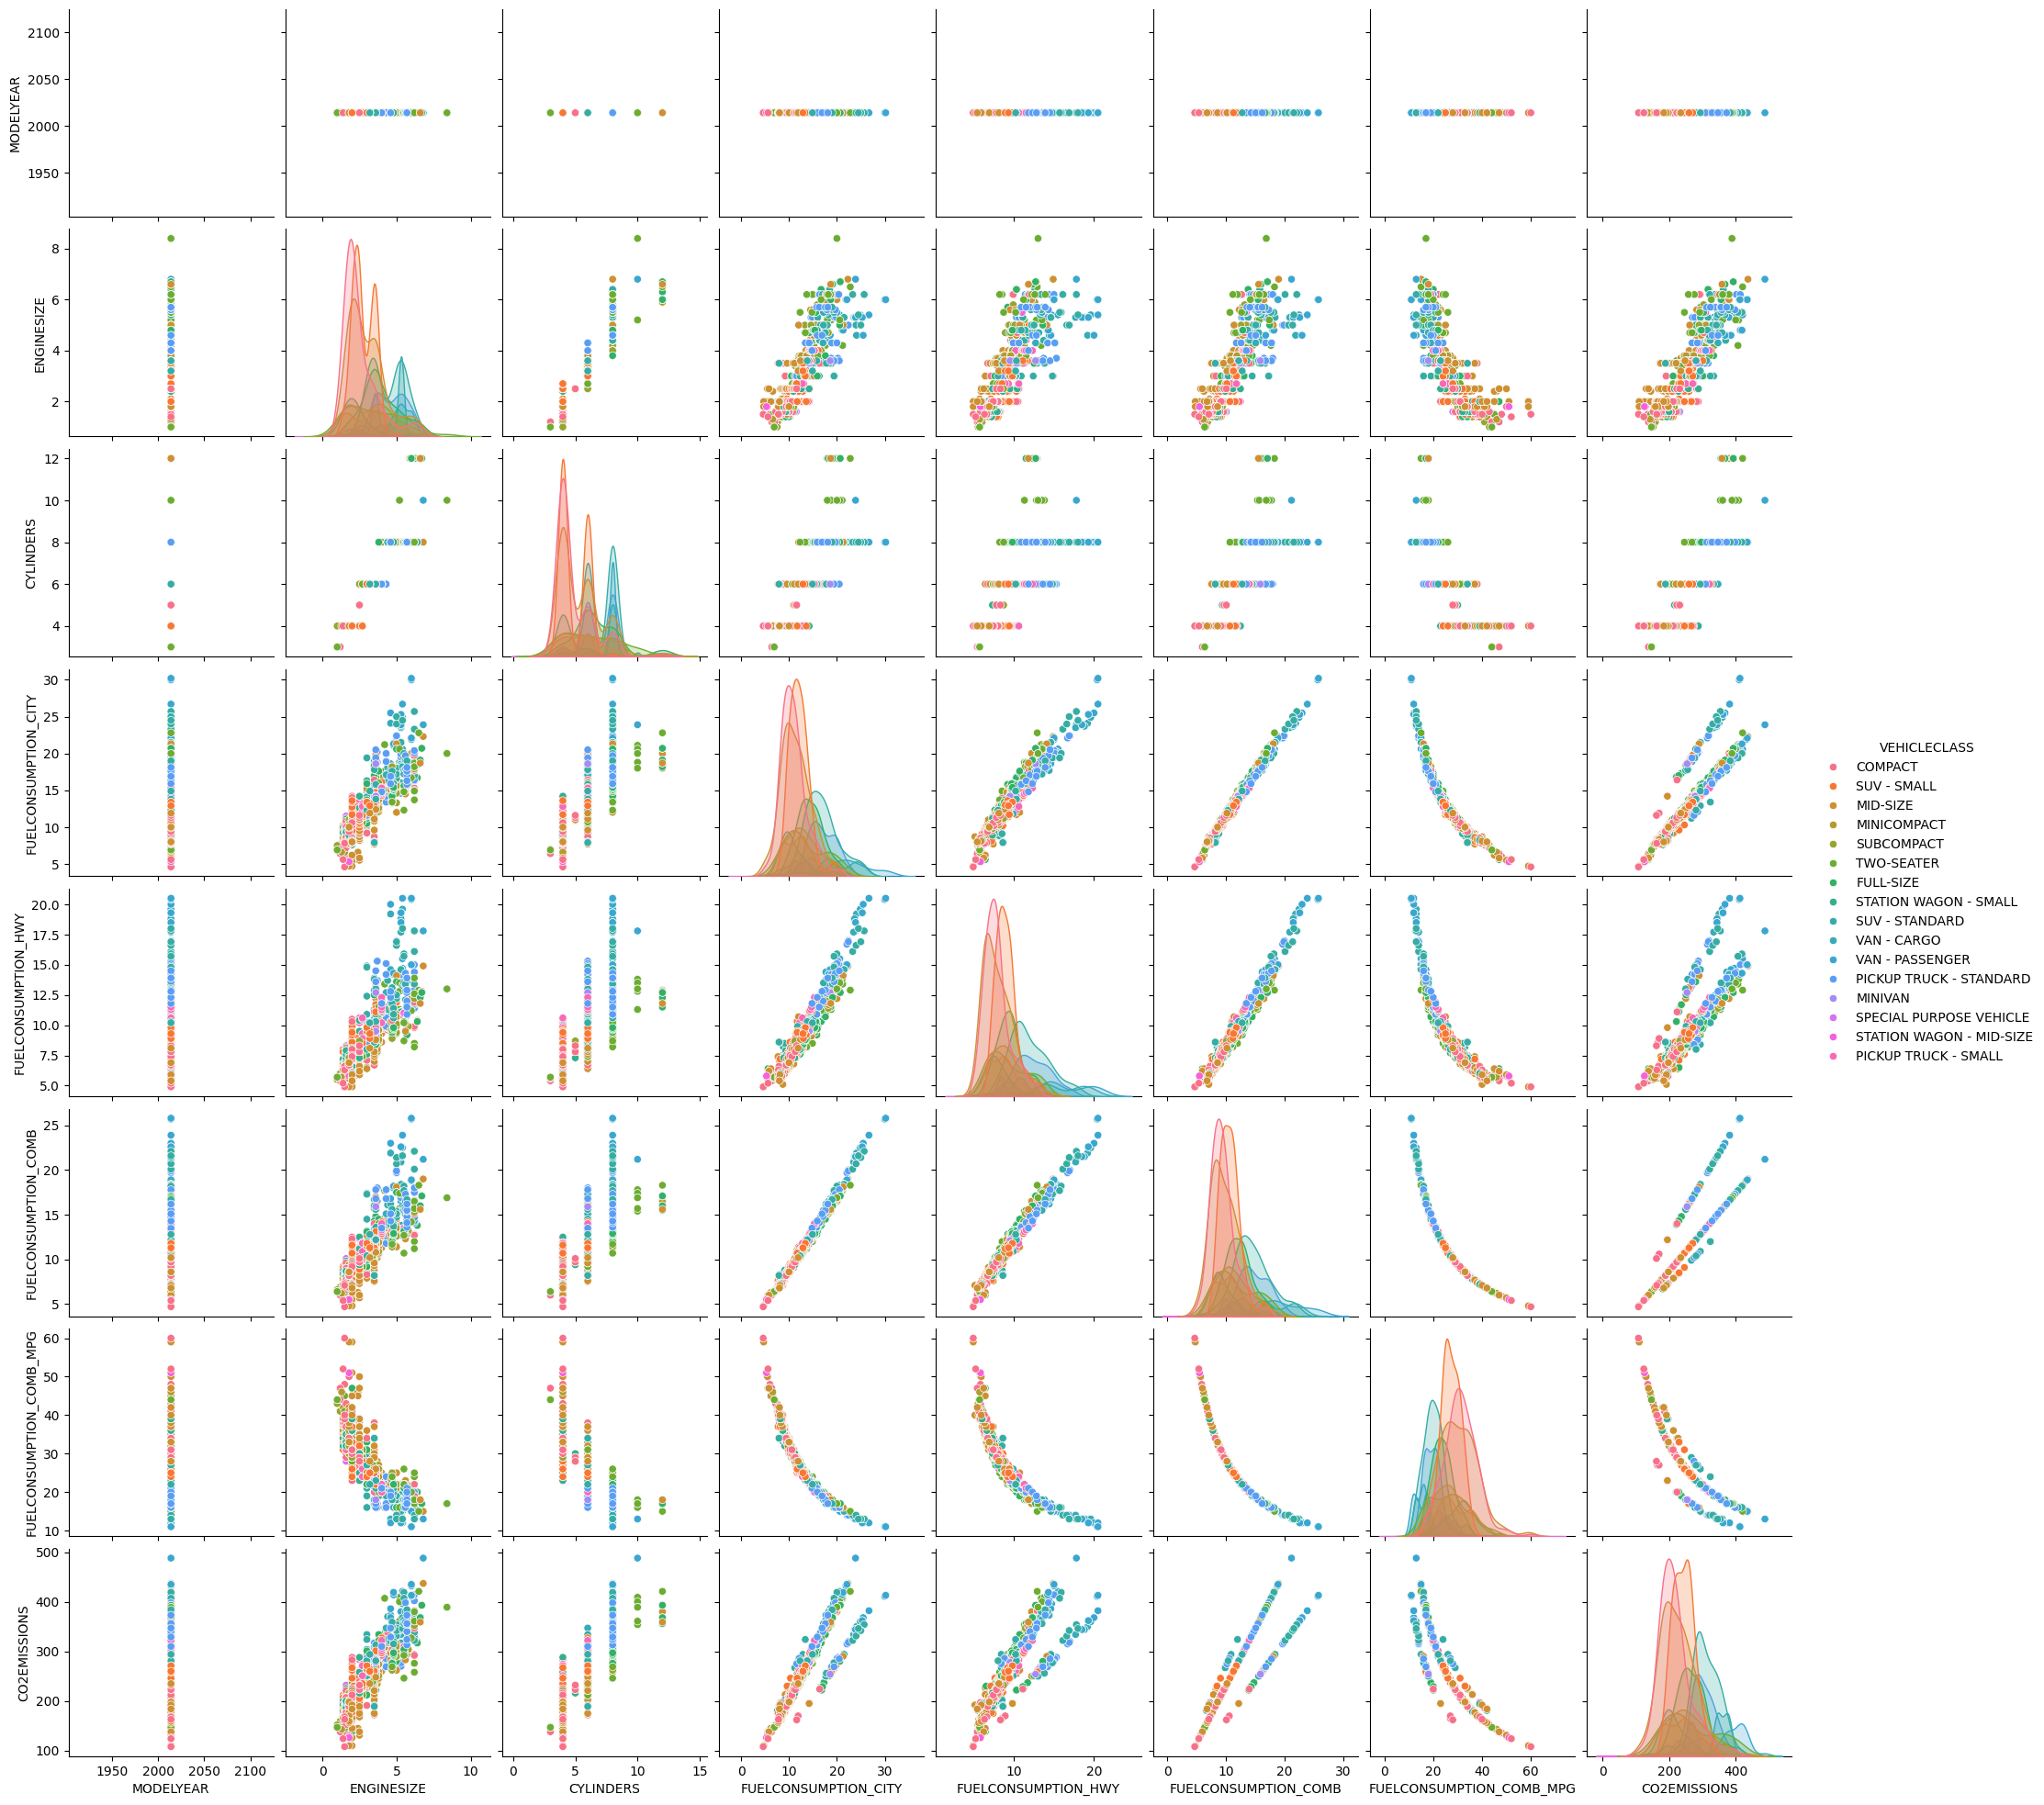

In [12]:
#Checking how vehicleclasas relates to those patterns
sns.pairplot(df, hue = "VEHICLECLASS")


The pairplot now shows the same relationships but introducing a categorical dimension which is vehicle class.
* Separation between vehicle classes: Smaller/compact classes tend to be concentrated in the lower-medium ranges of variaables suhc as engine size, cylinder fuel consumption. while larger vehicles and vans tend to occupy medium-high ranges
* Overlap between classes: There is also a considerable overlap betweeen the vehicle classes for instance visible by enginesize, indicating that these variables alone, can not distinguish the classes. Fuel cunsumption variable shows less overlap, hence greater separation.
* Clusters along existing relationships: There are some observable clusters among the classes, particularly at a higher ranges of engine size and cylinder count, where larger vehicles are concentrated.

Vehiucle class help me discover patterns that were not visible in the origial pairplot, indicating that some of the variables may be associalted with vehicle class, although overlapp remains.

Text(0.5, 1.0, 'Correlation Heatmap')

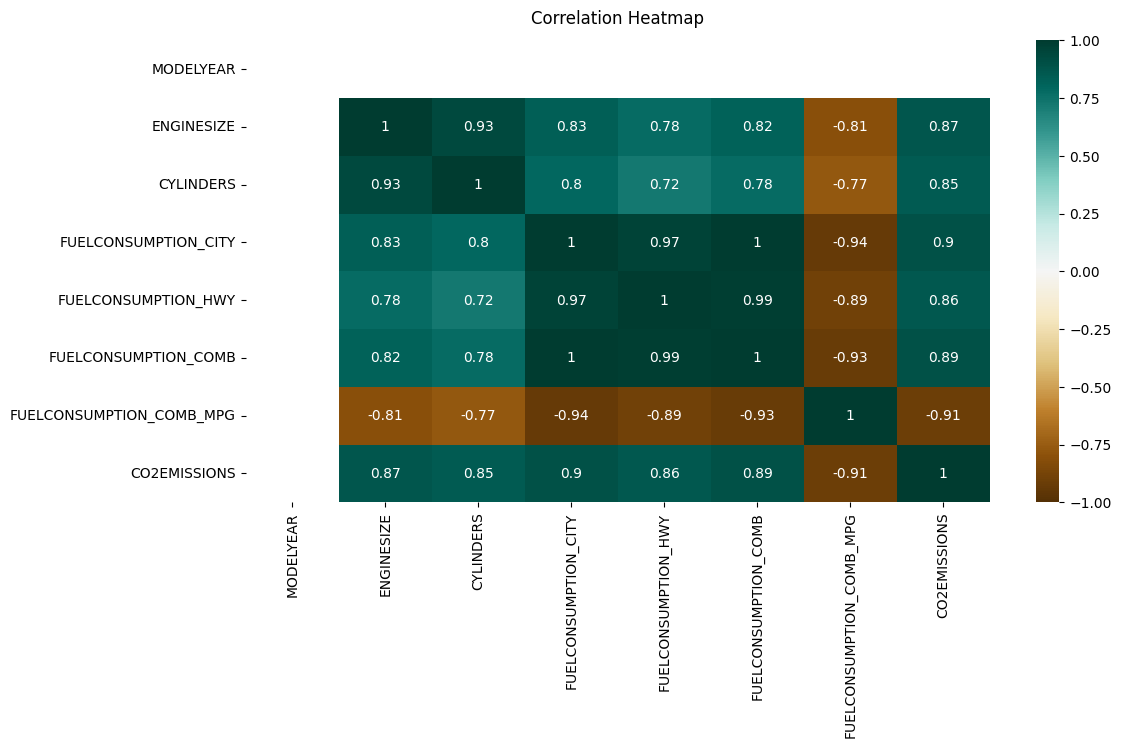

In [13]:
# Correlation heatmap for numeric values only (quantifying the correlation)
plt.figure(figsize=(12, 6))
heatmap = sns.heatmap(df.corr(numeric_only=True), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12)

Observations: 
* ModelYear has no correlation values (NaN), as discovered earlier, there is only one year obseravtion from 2014. Wit no variation, not correlation can be calulated.
* Overall, there is a strong to very strong positive and negative corellation between variables: 
- engine-cylinder (0.93): vehicles with larger engines tend to have more cylinders
- enginge_co2 emission (0.87): vehicles with larger engines, cylinders (0.85) tend to be associaated with a higher CO2 emission, but strong negative correlation with Combined mpg (-0.91)
- Fuel consumption measures: (comb, comb mpg, city, hwy) shows a strong positive relationship with each other and CO2 emission
- Fuel consumption comb mpg: has a strong negative relationship across all veriables (expected)

NOTE: there is an observed string correlations across variable pair, hence a potential signal for multicollinearity.

## Plot to check the linearity

## Data exploration

In [14]:
# Summarise the data and create small DF with only selected variables
print(df.describe())
cdf=df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head(9)

       MODELYEAR   ENGINESIZE    CYLINDERS  FUELCONSUMPTION_CITY  \
count     1067.0  1067.000000  1067.000000           1067.000000   
mean      2014.0     3.346298     5.794752             13.296532   
std          0.0     1.415895     1.797447              4.101253   
min       2014.0     1.000000     3.000000              4.600000   
25%       2014.0     2.000000     4.000000             10.250000   
50%       2014.0     3.400000     6.000000             12.600000   
75%       2014.0     4.300000     8.000000             15.550000   
max       2014.0     8.400000    12.000000             30.200000   

       FUELCONSUMPTION_HWY  FUELCONSUMPTION_COMB  FUELCONSUMPTION_COMB_MPG  \
count          1067.000000           1067.000000               1067.000000   
mean              9.474602             11.580881                 26.441425   
std               2.794510              3.485595                  7.468702   
min               4.900000              4.700000                 11.000000 

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


Connecting dataset to pairplot observations:
* ModelYear -  With only one value (2014) data doesn't have predictive information within this dataset.
* Engine size - mean (3.34) and median (3.4) showing very similar values, suggesting approximate symmetric distribution. The max value of 8.4 indicates some high-end obsverations vs centre of the distribution.
* Cylinders - mean 5.79, vs median 6.0, showing very close values. The variabel is dicrete with values reaching 12.
* Across fuels consumption - mean is higher than median, consistent with the right-skewness obsvered earlier. There are also high-end observarions in the upper tail.
* CO2 emission - mean is higher than median, suggesting some right skeweness, high-end values are present.

## Potential Predictors evaluation vs target (Emission)

Evalauting relationship across numeric variables

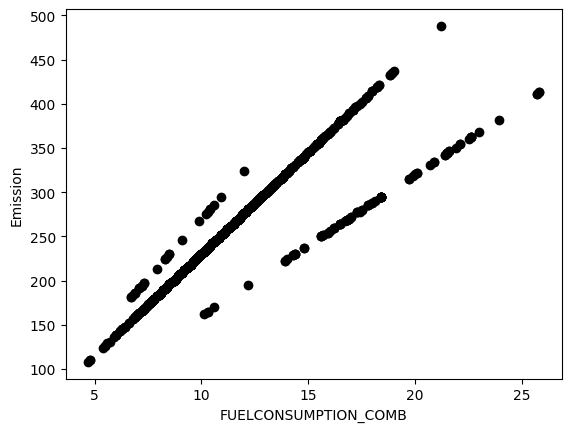

In [15]:
plt.scatter(cdf.FUELCONSUMPTION_COMB,cdf.CO2EMISSIONS, color='black')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

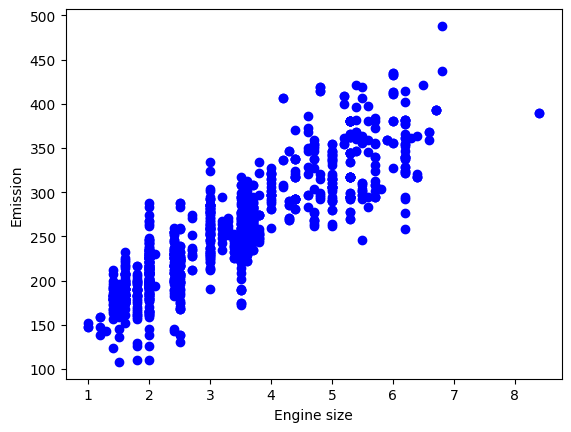

In [16]:
plt.scatter(cdf.ENGINESIZE,cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

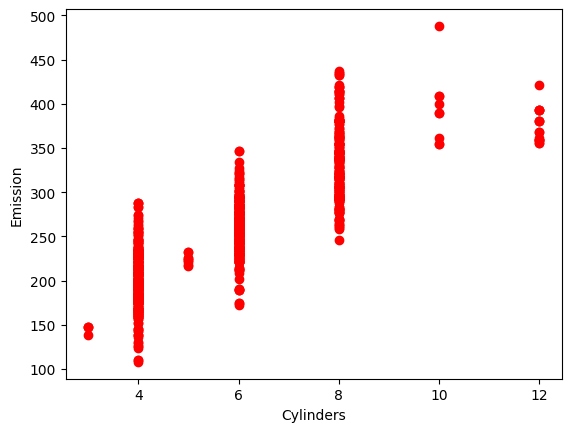

In [17]:
plt.scatter(cdf.CYLINDERS,cdf.CO2EMISSIONS, color='red')
plt.xlabel("Cylinders")
plt.ylabel("Emission")
plt.show()

Observation: 
* Fuel consumption combined shows a clear positive relationship with emission with some visible banded concentration pof obsevrations
* Cylineders show also a positive relationship with emission with some visible vertical banded concentration of obsevrations, given cylinders discrete values
* Engine size shows a clear positive, approximaytely linear relationship with emission. Observations are concentrated around the entire trend, with some dispersio (from low to higher ranges) and one visual extreme observation.    


Which of the above variables do you think will work best to explain a linear relation with CO2 emission?
* Engine Size may be a useful predictor, but I can not conclude if this is the strongest predictor based on the plot alone.

## Demo 2. Regression

## Train-test data preparation

In [18]:
# Generating radnom number between 0 and 1, turning into True/False values for 80% being True. Training set takes Trues, Test takes the remaining False observations.

msk=np.random.rand(len(df))<0.8
train=cdf[msk]
test=cdf[~msk]

In [19]:
#Verify
print('Training:', train.shape) 
print('Testing:', test.shape) 

Training: (870, 4)
Testing: (197, 4)


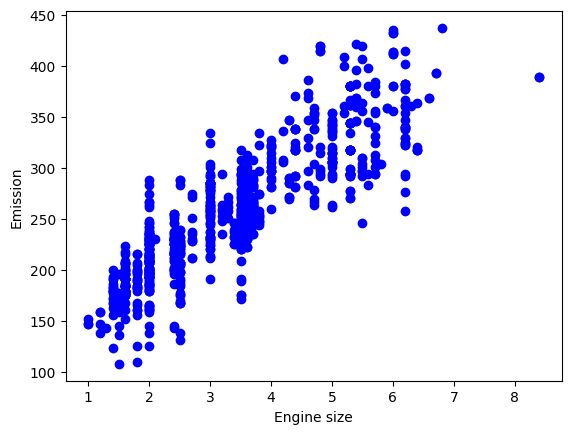

In [20]:
# Train data distribution
plt.scatter(train.ENGINESIZE,train.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

The variables ralationship present on the full dataset is present in the randonly selected training data, showing similar approximately linear pattern. 

## Using sklearn package for data modelling

Note: the training set contain 3 predictors but only one of them use used, hence this needs to be specified.

* X = Engine Size
* y = CO₂ Emissions

In [21]:
from sklearn import linear_model
regr=linear_model.LinearRegression()
train_x=np.asanyarray(train[['ENGINESIZE']])
train_y=np.asanyarray(train[['CO2EMISSIONS']])

regr.fit(train_x, train_y)
# The coefficients
print('Coefficients:', regr.coef_)
print('Intercept:', regr.intercept_)

Coefficients: [[38.86666736]]
Intercept: [126.29409726]


**Model: Predicted Co2 = 122.89 + 39.80 x Engine Size**

For each unit increase in engine size, the predicted CO2 increases by apprpoximately 39%, on average.

**Note: I can use Pandas instead of NumPhy**

X_train = train[['ENGINESIZE']]

y_train = train['CO2EMISSIONS']

regr.fit(X_train, y_train)

Text(0, 0.5, 'Emission')

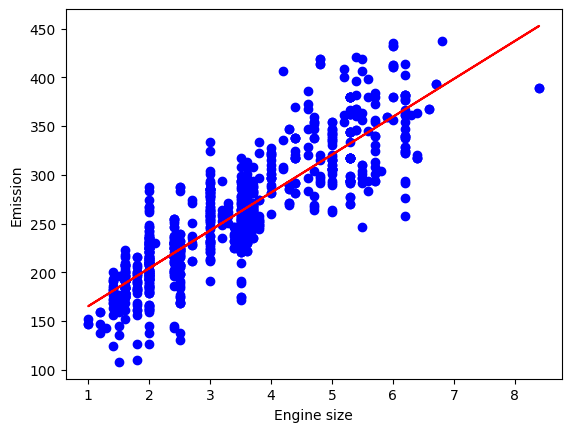

In [22]:
# Plot outputs
plt.scatter(train.ENGINESIZE,train.CO2EMISSIONS,color='blue')
plt.plot(train_x,regr.coef_[0][0]*train_x + regr.intercept_[0],'-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

Note: Instead of calulating the regression line manually --> plt.plot(regr.coef_[0][0] * train_x + regr.intercept_[0])

Using --> plt.plot(train.ENGINESIZE, regr.predict(train[['ENGINESIZE']]))


## Model evaluation

In [23]:
from sklearn.metrics import r2_score
test_x=np.asanyarray(test[['ENGINESIZE']])
test_y=np.asanyarray(test[['CO2EMISSIONS']])
test_y_ = regr.predict(test_x)

In [24]:
print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_-test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_-test_y)**2))
print("R2-score: %.2f" % r2_score(test_y,test_y_))

Mean absolute error: 22.18
Residual sum of squares (MSE): 880.23
R2-score: 0.78


Tye simple linear regression using engine size show strong predictive performance, explainin approximately 79% of the variation in CO2 emission in the test data, with a mean absolute prediction error of 23.22.

# 2. Nonlinear regression - China GDP example

#### Importing reqired dataset

In [26]:
df=pd.read_csv("data/china_gdp.csv")
df.head(10)

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10
5,1965,6.970915e+10
6,1966,7.587943e+10
7,1967,7.205703e+10
8,1968,6.999350e+10
9,1969,7.871882e+10


#### Plotting the dataset

* x_data = Year
* y_data = GDP (Value)
* 'ro' = red (r) circles (o)

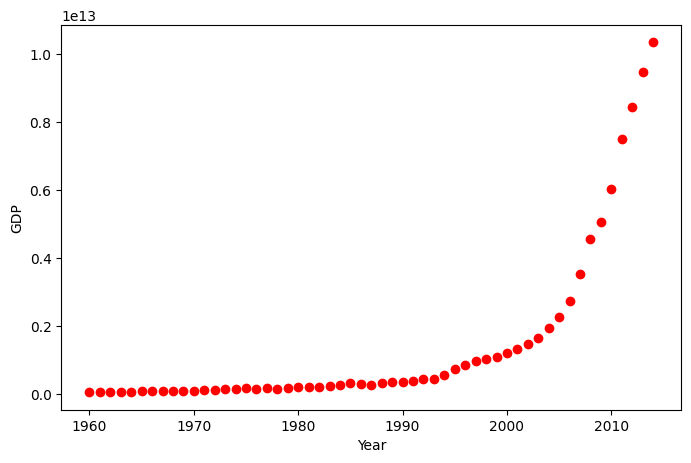

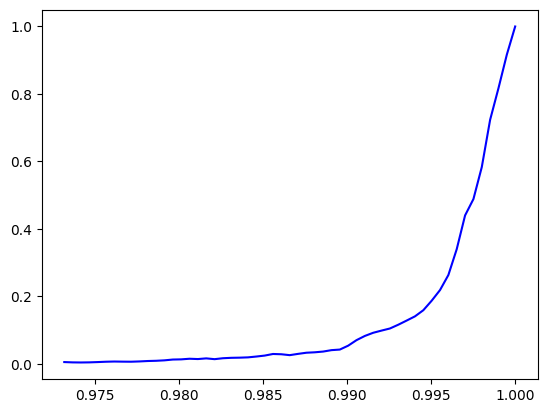

In [ ]:
plt.figure(figsize=(8,5))

x_data,y_data=(df["Year"].values,df["Value"].values)

plt.plot(x_data,y_data,'ro')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

# Normalisation; Rescaling both variables relative to their maximum.
xdata=x_data/max(x_data)
ydata=y_data/max(y_data)

plt.plot(xdata,ydata,'b')

Roughly looking look at the data visualisation, it appears that the logistic function could be a good representation for this very dataset. The logistic function has the property of starting with a slow growth, increasing growth in the middle, and then decreasing again at the end.

**Linear: y = intercept + coefficient × x**

**Sigmoid: y = 1 / (1 + exp(-β₁(x - β₂)))**

#### Implement the logistic function (Logistic Regression)

Sigmoid function produces an S-shaped curve.
* x- input
* y - predicted normalised GDP
* Beta_1 - controls how steep the curve is
* Beta_2 - controls where the curve's midpoint/turning region occurs

In [ ]:
def sigmoid(x,Beta_1,Beta_2):
    y=1/(1+np.exp(-Beta_1*(x-Beta_2)))
    return y

#### Fit the logistic function on this dataset and estimate the relevant parameters

beta_1=690.451712,beta_2=0.997207


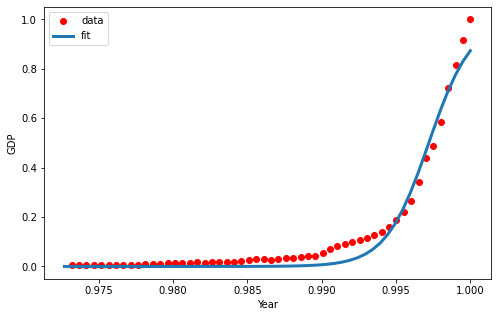

In [ ]:
from scipy.optimize import curve_fit
popt,pcov=curve_fit(sigmoid,xdata,ydata)
print("beta_1=%f,beta_2=%f"%(popt[0],popt[1]))

##
x=np.linspace(1960,2015,55)
x=x/max(x)
plt.figure(figsize=(8,5))
y=sigmoid(x,*popt)

plt.plot(xdata,ydata,'ro',label='data')
plt.plot(x,y,linewidth=3.0,label='fit')
plt.legend(loc='best')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

### SUMMARY: 

**Linear Regression:** Explore → select X and y → train/test split → fit → regression line → predict → evaluate (MAE, MSE, R²)

**Non_Linear Regression:**  Plot → see curved relationship → normalize → define sigmoid → fit curve → plot fitted curve